In [152]:
import matplotlib.pyplot as plt   
import numpy as np               
import pandas as pd             
import warnings
warnings.filterwarnings('ignore')

In [153]:

dates = pd.bdate_range('2019-01-01', '2023-12-31')

n = len(dates)   

np.random.seed(42)         
daily_log_returns = np.random.normal(0.0005, 0.013, n)

for i, d in enumerate(dates):
    if pd.Timestamp('2020-02-20') <= d <= pd.Timestamp('2020-03-23'):
        daily_log_returns[i] = np.random.normal(-0.025, 0.02)  

close_prices = 1000.0 * np.exp(np.cumsum(daily_log_returns))


volume = (np.random.lognormal(15, 0.4, n) * (1 + 4*np.abs(daily_log_returns)/np.abs(daily_log_returns).max())).astype(int)

df = pd.DataFrame({
    'Close' : close_prices,
    'Volume': volume
}, index=dates)
df.index.name = 'Date'

print(f"Rows: {len(df)}  |  Close range: ₹{df['Close'].min():.0f} – ₹{df['Close'].max():.0f}")

Rows: 1304  |  Close range: ₹570 – ₹1850


In [154]:

df['Daily_Return'] = df['Close'].pct_change() * 100


df['Rolling_Vol'] = df['Daily_Return'].rolling(30).std() * np.sqrt(252)

print(df[['Close', 'Daily_Return', 'Rolling_Vol']].tail(3))

                  Close  Daily_Return  Rolling_Vol
Date                                              
2023-12-27  1831.833053      1.348669    21.442495
2023-12-28  1828.585390     -0.177290    20.974263
2023-12-29  1811.613655     -0.928135    21.173478


Figure created. 4 axes ready: ax1 (top-left), ax2 (top-right),
                               ax3 (bottom-left), ax4 (bottom-right)


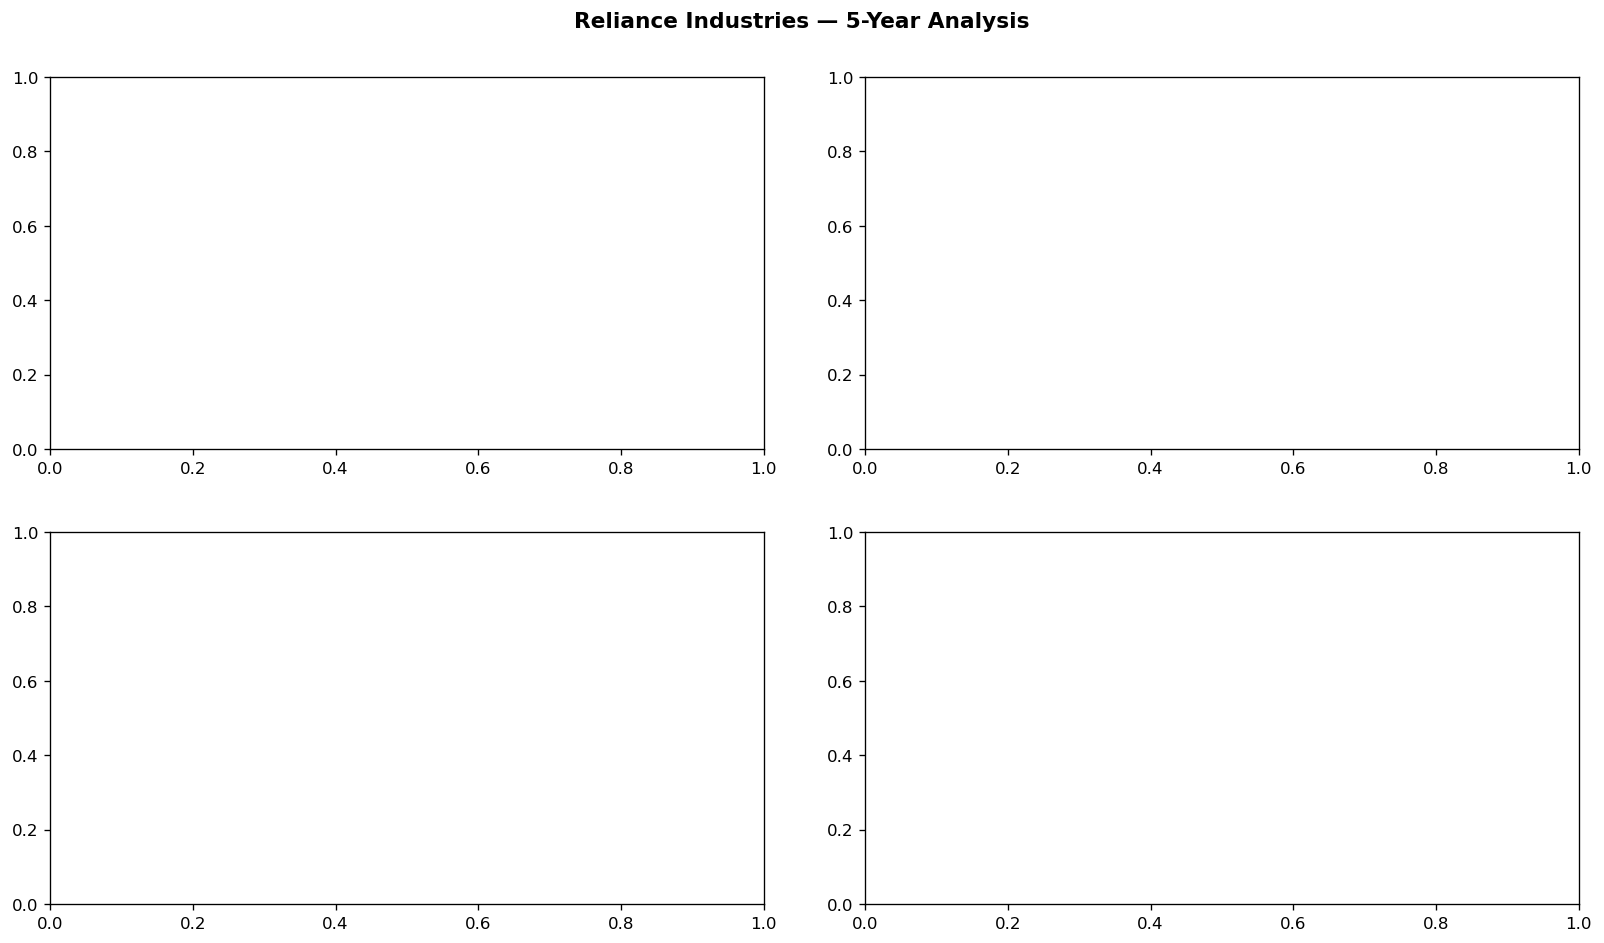

In [155]:

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2,
    figsize=(14, 8),
    dpi=120
)

fig.tight_layout(pad=3.0)   

fig.suptitle('Reliance Industries — 5-Year Analysis',
             fontsize=13, fontweight='bold', y=1.01)


print('Figure created. 4 axes ready: ax1 (top-left), ax2 (top-right),')
print('                               ax3 (bottom-left), ax4 (bottom-right)')

In [156]:

ax1.plot(df.index, df['Close'],
         color='steelblue',  
         linewidth=1.2, 
         label='Close price') 

ma200 = df['Close'].rolling(200).mean()
ax1.plot(df.index, ma200,
         color='orange',
         linewidth=1.0,
         linestyle='--',     
         alpha=0.8,     
         label='200-day MA')

ax1.set_title('① Closing Price', fontsize=10, fontweight='bold')
ax1.set_ylabel('Price (₹)')
ax1.legend(fontsize=8)      
ax1.grid(True, alpha=0.3)     

In [157]:

crash_start  = '2020-02-20'   
crash_bottom = '2020-03-23' 


ax1.axvspan(
    crash_start, crash_bottom,
    color='red',
    alpha=0.15   
)


ax1.axvline(
    x=pd.Timestamp(crash_bottom),
    color='red',
    linewidth=1.0,
    linestyle='--',
    alpha=0.8
)


ax1.text(
    0.38, 0.06,          
    'COVID crash\nMar 2020', 
    transform=ax1.transAxes,
    fontsize=8,
    color='red',
    ha='center'           
)

Text(0.38, 0.06, 'COVID crash\nMar 2020')

In [158]:

returns = df['Daily_Return'].dropna()

ax2.hist(
    returns,
    bins=50,
    color='steelblue',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.8
)

ax2.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)

ax2.set_title('② Daily Returns Distribution', fontsize=10, fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency (number of days)')
ax2.grid(True, alpha=0.3)

mu    = returns.mean()
sigma = returns.std()
ax2.text(0.97, 0.95,
         f'Mean: {mu:.2f}%\nStd:  {sigma:.2f}%',
         transform=ax2.transAxes,
         fontsize=8, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

Text(0.97, 0.95, 'Mean: 0.05%\nStd:  1.34%')

In [159]:

vol = df['Rolling_Vol'].dropna()
ax3.plot(vol.index, vol,
         color='purple',
         linewidth=1.2,
         label='30-day vol')

ax3.fill_between(vol.index, 0, vol, color='purple', alpha=0.12)

ax3.set_title('③ Rolling 30-Day Volatility', fontsize=10, fontweight='bold')
ax3.set_ylabel('Volatility % (annualised)', color='purple')
ax3.tick_params(axis='y', labelcolor='purple') 
ax3.set_ylim(0, None)   
ax3.grid(True, alpha=0.3)

ax3b = ax3.twinx()    
ax3b.plot(df.index, df['Close'],
          color='steelblue',
          linewidth=0.8,
          alpha=0.25,        
          label='Price')
ax3b.set_ylabel('Price (₹)', color='steelblue', alpha=0.6)
ax3b.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

ax3.axvspan('2020-02-20', '2020-03-23', color='red', alpha=0.12)
ax3.axvline(pd.Timestamp('2020-03-23'), color='red', lw=1, ls='--', alpha=0.7)

In [160]:

monthly_vol = df['Volume'].resample('ME').mean() / 1_000_000  
monthly_ret = df['Close'].resample('ME').last().pct_change()

bar_colours = [
    'green' if r >= 0 else 'red'
    for r in monthly_ret.reindex(monthly_vol.index, fill_value=0)
]

ax4.bar(monthly_vol.index, monthly_vol,
        width=20,
        color=bar_colours,
        alpha=0.75)

ax4.set_title('④ Monthly Avg Volume', fontsize=10, fontweight='bold')
ax4.set_ylabel('Volume (millions)')
ax4.grid(True, alpha=0.3, axis='y')  

ax4.axvspan('2020-02-20', '2020-03-23', color='red', alpha=0.15)
ax4.axvline(pd.Timestamp('2020-03-23'), color='red', lw=1, ls='--', alpha=0.7)
ax4.text(0.33, 0.93, 'COVID',
         transform=ax4.transAxes, fontsize=8, color='red', va='top')

Text(0.33, 0.93, 'COVID')

In [161]:

fig.tight_layout(pad=3.0)


fig.savefig(
    '../images/week3_day2_chart.png',
    dpi=150,
    bbox_inches='tight'
)

print('Figure saved to images/week3_day2_chart.png')
plt.show() 

Figure saved to images/week3_day2_chart.png
